# **LOAD THE DATASET:**

In [70]:
%pip install datasets
%pip install tensorflow
%pip install gensim
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


**Loading and splitting the dataset into train, test and validation:**

In [71]:
from datasets import load_dataset, load_metric
dataset = load_dataset("surrey-nlp/PLOD-CW")

In [72]:
dataset

DatasetDict({
    train: Dataset({
        features: ['tokens', 'pos_tags', 'ner_tags'],
        num_rows: 1072
    })
    validation: Dataset({
        features: ['tokens', 'pos_tags', 'ner_tags'],
        num_rows: 126
    })
    test: Dataset({
        features: ['tokens', 'pos_tags', 'ner_tags'],
        num_rows: 153
    })
})

In [73]:
train_dataset = dataset["train"]
validation_dataset = dataset["validation"]
test_dataset = dataset["test"]

In [74]:
X_train_data = [' '.join(sublist) for sublist in train_dataset['tokens']]
X_test_data = [' '.join(sublist) for sublist in test_dataset['tokens']]
X_val_data = [' '.join(sublist) for sublist in val_dataset['tokens']]

In [75]:
type(X_train_data)

list

**Encoding the 'ner_tags':**

In [76]:
y_train_labels = train_dataset['ner_tags']
y_test_labels = test_dataset['ner_tags']
y_val_labels = val_dataset['ner_tags']

In [77]:
from sklearn.preprocessing import MultiLabelBinarizer

y_train_labels = train_dataset['ner_tags']
y_test_labels = test_dataset['ner_tags']
y_val_labels = val_dataset['ner_tags']

y_train_label_list = y_train_labels
y_test_label_list = y_test_labels
y_val_label_list = y_val_labels


encoder = MultiLabelBinarizer()

y_train = encoder.fit_transform(y_train_label_list)
y_test = encoder.fit_transform(y_test_label_list)
y_val = encoder.fit_transform(y_val_label_list)

# **WORD2VEC:**

**Importing the required libraries:**

In [78]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
import gensim.downloader as api
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import torch.nn as nn
import torch.optim as optim


**Pre-trained word2vec model:**

In [79]:
word2vec_model = api.load('word2vec-google-news-300')

**Tokenization:**

In [80]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_data)
X_train_sequence = tokenizer.texts_to_sequences(X_train_data)
X_test_sequence = tokenizer.texts_to_sequences(X_test_data)
X_val_sequence = tokenizer.texts_to_sequences(X_val_data)

**Padding:**

In [81]:
max_seq_len = 323
X_train_pad = pad_sequences(X_train_sequence, maxlen=max_seq_len)
X_test_pad = pad_sequences(X_test_sequence, maxlen=max_seq_len)
X_val_pad = pad_sequences(X_val_sequence, maxlen=max_seq_len)

**Word2Vec Embedding:**

In [82]:
import numpy as np
vocab_size= len(tokenizer.word_index) +1
embedding_dim = 300
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
  if word in word2vec_model:
    embedding_matrix[i] = word2vec_model[word]

**RNN with WORD2VEC:**

In [83]:
# Define label encoding
label_encoding = {"B-O": 0, "B-AC": 1, "B-LF": 2, "I-LF": 3}

# Corrected function for preparing data
def prepare_data(dataset, word2vec_model, label_encoding, max_len=128):
    input_vectors = []
    labels = []
    
    for data in dataset:
        tokens = data['tokens']
        ner_tags = data['ner_tags']
        
        # Convert tokens to word vectors
        word_vectors = []
        for token in tokens:
            if token in word2vec_model:
                word_vectors.append(word2vec_model[token])
            else:
                word_vectors.append(np.zeros(word2vec_model.vector_size))
        
        # Pad or truncate word vectors to max_len
        if len(word_vectors) > max_len:
            word_vectors = word_vectors[:max_len]
        else:
            pad_length = max_len - len(word_vectors)
            word_vectors.extend([np.zeros(word2vec_model.vector_size)] * pad_length)
        
        input_vectors.append(np.array(word_vectors))  # Convert to numpy array
        
        # Convert NER tags to numerical labels, padding or truncating to max_len
        numerical_tags = [label_encoding.get(tag, -1) for tag in ner_tags]
        if len(numerical_tags) > max_len:
            numerical_tags = numerical_tags[:max_len]  # Truncate if too long
        else:
            numerical_tags += [-1] * (max_len - len(numerical_tags))  # Pad if too short
        
        labels.append(torch.tensor(numerical_tags))
    
    # Convert lists to tensors
    input_vectors = torch.tensor(input_vectors, dtype=torch.float32) 
    labels = torch.stack(labels)
    
    return TensorDataset(input_vectors, labels)

# Prepare datasets for training, validation, and testing
train_data = prepare_data(train_dataset, word2vec_model, label_encoding)
validation_data = prepare_data(validation_dataset, word2vec_model, label_encoding)
test_data = prepare_data(test_dataset, word2vec_model, label_encoding)

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_dim, output_dim, n_layers=1, dropout=0.3):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, input_vectors):
        rnn_out, _ = self.rnn(input_vectors)
        output = self.fc(rnn_out)
        
        return output

# Model parameters
input_size = word2vec_model.vector_size  # Size of word vectors
hidden_dim = 128 
output_dim = len(label_encoding)  # Number of unique labels

# Create the model
model = RNNModel(input_size, hidden_dim, output_dim)

# Define the loss function with ignore_index
criterion = nn.CrossEntropyLoss(ignore_index=-1)
optimizer = optim.Adam(model.parameters(), lr=0.001) 

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for input_vectors, labels in train_loader:
        optimizer.zero_grad()  # Reset gradients
        
        outputs = model(input_vectors)  # Forward pass
        
        # Flatten for loss computation
        logits_flat = outputs.view(-1, outputs.shape[-1])
        labels_flat = labels.view(-1)
        
        # Calculate loss, ignoring padding tokens
        loss = criterion(logits_flat, labels_flat)
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}")

# Evaluation
model.eval()
predictions = []
ground_truth = []

with torch.no_grad():
    for input_vectors, labels in test_loader:
        outputs = model(input_vectors)  # Forward pass
        preds = torch.argmax(outputs, dim=-1)  # Get the predicted class/label
        
        # Store predictions and ground truth, converting them to numpy arrays
        predictions.append(preds.cpu().numpy())
        ground_truth.append(labels.cpu().numpy())

# Flatten the arrays for evaluation and concatenate all predictions/labels
flat_predictions = np.concatenate([arr.flatten() for arr in predictions])
flat_ground_truth = np.concatenate([arr.flatten() for arr in ground_truth])

# Remove instances where the label is -1 (padding/ignored)
valid_indices = flat_ground_truth != -1  
filtered_predictions = flat_predictions[valid_indices]  
filtered_ground_truth = flat_ground_truth[valid_indices]  

# Generate the classification report using only valid data
print(classification_report(
    filtered_ground_truth,
    filtered_predictions,
    zero_division=0 
))


/user/HS402/jj01056/.local/lib/python3.10/site-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Epoch 1, Loss: 44.5043
Epoch 2, Loss: 32.1654
Epoch 3, Loss: 29.1674
Epoch 4, Loss: 27.6231
Epoch 5, Loss: 26.6090
Epoch 6, Loss: 25.8092
Epoch 7, Loss: 24.7212
Epoch 8, Loss: 24.8291
Epoch 9, Loss: 23.8708
Epoch 10, Loss: 23.0892
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      4292
           1       0.74      0.53      0.61       270
           2       0.29      0.18      0.22       150
           3       0.40      0.32      0.35       288

    accuracy                           0.86      5000
   macro avg       0.58      0.49      0.53      5000
weighted avg       0.85      0.86      0.85      5000



**Evaluation Metrics:**

In [84]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

conf_matrix = confusion_matrix(filtered_ground_truth, filtered_predictions)
accuracy_word2vec = accuracy_score(filtered_ground_truth, filtered_predictions)
precision_word2vec = precision_score(filtered_ground_truth, filtered_predictions, average='weighted')
recall_word2vec = recall_score(filtered_ground_truth, filtered_predictions, average='weighted')
f1_word2vec = f1_score(filtered_ground_truth, filtered_predictions, average='weighted')

print(classification_report(filtered_ground_truth, filtered_predictions, zero_division=0))
print("Accuracy:", accuracy_word2vec)
print("Precision:", precision_word2vec)
print("Recall:", recall_word2vec)
print("F1 Score:", f1_word2vec)


              precision    recall  f1-score   support

           0       0.91      0.95      0.93      4292
           1       0.74      0.53      0.61       270
           2       0.29      0.18      0.22       150
           3       0.40      0.32      0.35       288

    accuracy                           0.86      5000
   macro avg       0.58      0.49      0.53      5000
weighted avg       0.85      0.86      0.85      5000

Accuracy: 0.864
Precision: 0.8483822310407171
Recall: 0.864
F1 Score: 0.8541998592305595


**Confusion Matrix:**

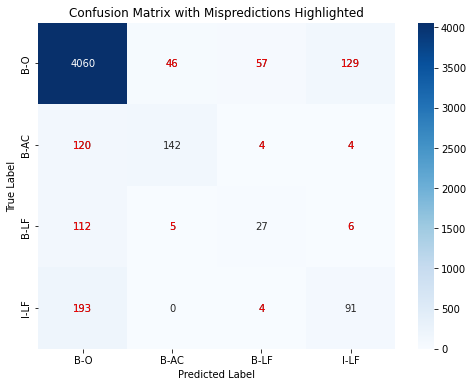

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=label_encoding.keys(), yticklabels=label_encoding.keys())

# Highlight mispredicted values in red
for i in range(len(label_encoding)):
    for j in range(len(label_encoding)):
        if i != j and conf_matrix[i, j] > 0:
            plt.text(j + 0.5, i + 0.5, conf_matrix[i, j], color='red', ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix with Mispredictions Highlighted")
plt.show()


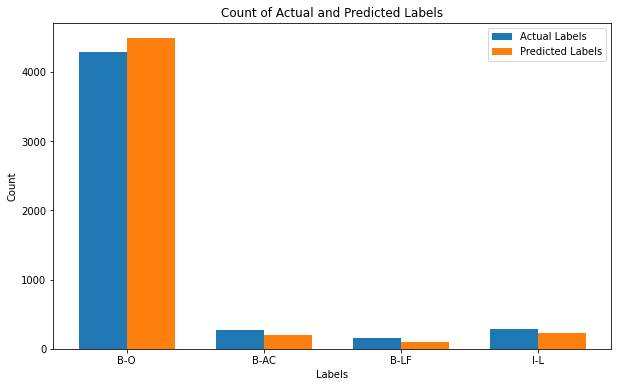

In [86]:
import matplotlib.pyplot as plt
import numpy as np


flat_predictions = np.concatenate([arr.flatten() for arr in predictions])
flat_ground_truth = np.concatenate([arr.flatten() for arr in ground_truth])


valid_indices = flat_ground_truth != -1  
filtered_predictions = flat_predictions[valid_indices]  
filtered_ground_truth = flat_ground_truth[valid_indices] 


label_names = list(label_encoding.keys())


actual_label_names = ['B-O', 'B-AC', 'B-LF', 'I-L']


actual_label_count = {label: list(filtered_ground_truth).count(label_encoding[label]) for label in label_names}


predicted_label_count = {label: list(filtered_predictions).count(label_encoding[label]) for label in label_names}


fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = np.arange(len(label_names))

actual_bars = ax.bar(index, actual_label_count.values(), bar_width, label='Actual Labels')
predicted_bars = ax.bar(index + bar_width, predicted_label_count.values(), bar_width, label='Predicted Labels')

ax.set_xlabel('Labels')
ax.set_ylabel('Count')
ax.set_title('Count of Actual and Predicted Labels')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(actual_label_names)  # Set actual label names as tick labels
ax.legend()

plt.show()


# TF-IDF:

**Importing the required libraries:**

In [88]:
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf

**Model Builiding:**

In [89]:
# Convert text data to TF-IDF vectors
tfidf_vectorizer = TfidfVectorizer(max_features=5000) 
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_data)
X_test_tfidf = tfidf_vectorizer.transform(X_test_data)
X_val_tfidf = tfidf_vectorizer.transform(X_val_data)

# Reshape TF-IDF vectors to include timestep dimension
X_train_tfidf_reshaped = X_train_tfidf.toarray().reshape(X_train_tfidf.shape[0], 1, X_train_tfidf.shape[1])
X_test_tfidf_reshaped = X_test_tfidf.toarray().reshape(X_test_tfidf.shape[0], 1, X_test_tfidf.shape[1])
X_val_tfidf_reshaped = X_val_tfidf.toarray().reshape(X_val_tfidf.shape[0], 1, X_val_tfidf.shape[1])

# Define the RNN model
model_rnn_tfidf = Sequential([
    SimpleRNN(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(y_train.shape[1], activation='sigmoid')
])

# Compile the RNN model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_rnn_tfidf.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train the RNN model
history_rnn_tfidf = model_rnn_tfidf.fit(X_train_tfidf_reshaped, y_train,
                                        validation_data=(X_val_tfidf_reshaped, y_val),
                                        epochs=10, batch_size=32, verbose=1)

# Evaluate the RNN model on the test set
y_pred_rnn_tfidf = model_rnn_tfidf.predict(X_test_tfidf_reshaped)
y_pred_binary_rnn_tfidf = (y_pred_rnn_tfidf > 0.5)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.4957 - loss: 0.6299 - val_accuracy: 0.1032 - val_loss: 0.3579
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1339 - loss: 0.3535 - val_accuracy: 0.0794 - val_loss: 0.3228
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1167 - loss: 0.3030 - val_accuracy: 0.0794 - val_loss: 0.3138
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1040 - loss: 0.2246 - val_accuracy: 0.0794 - val_loss: 0.2906
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1181 - loss: 0.1533 - val_accuracy: 0.0794 - val_loss: 0.3058
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1059 - loss: 0.0767 - val_accuracy: 0.0794 - val_loss: 0.3529
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1100 - loss: 0.0450 - val_accuracy: 0.0794 - val_loss: 0.3980
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1013 - loss: 0.0249 - val_accuracy: 0.0794 - val_los

In [90]:

conf_matrix_rnn_tfidf = confusion_matrix(y_test.argmax(axis=1),
                                          y_pred_binary_rnn_tfidf.argmax(axis=1))
print("Confusion Matrix for RNN with TF-IDF:")
print(conf_matrix_rnn_tfidf)


print("Classification Report for RNN with TF-IDF:")
print(classification_report(y_test, y_pred_binary_rnn_tfidf, target_names=encoder.classes_))

accuracy_rnn_tfidf = accuracy_score(y_test, y_pred_binary_rnn_tfidf)
print("Accuracy for RNN with TF-IDF:", accuracy_rnn_tfidf)


f1_score_rnn_tfidf = f1_score(y_test, y_pred_binary_rnn_tfidf, average='weighted')
print("F1 Score for RNN with TF-IDF:", f1_score_rnn_tfidf)

Confusion Matrix for RNN with TF-IDF:
[[130   1]
 [ 15   7]]
Classification Report for RNN with TF-IDF:
              precision    recall  f1-score   support

        B-AC       0.90      0.99      0.94       131
        B-LF       0.80      0.96      0.88       113
         B-O       1.00      1.00      1.00       153
        I-LF       0.73      0.91      0.81       100

   micro avg       0.86      0.97      0.91       497
   macro avg       0.86      0.97      0.91       497
weighted avg       0.87      0.97      0.92       497
 samples avg       0.86      0.98      0.89       497

Accuracy for RNN with TF-IDF: 0.6470588235294118
F1 Score for RNN with TF-IDF: 0.9179605893319289


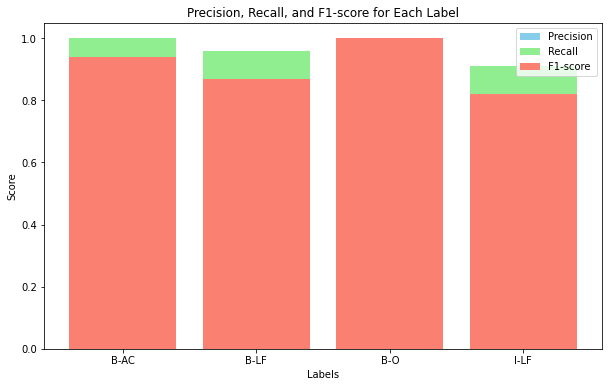

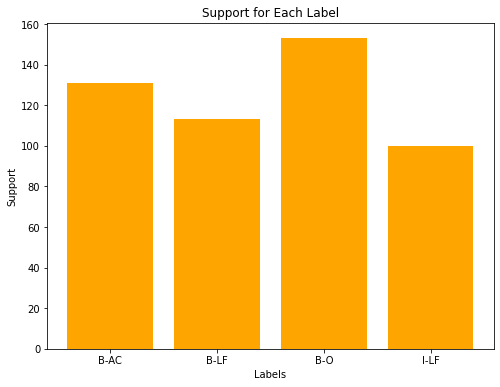

In [91]:
import matplotlib.pyplot as plt

# Define the label names
labels = ['B-AC', 'B-LF', 'B-O', 'I-LF']

# Precision values for each label
precision = [0.88, 0.80, 1.00, 0.75]

# Recall values for each label
recall = [1.00, 0.96, 1.00, 0.91]

# F1-score values for each label
f1_score = [0.94, 0.87, 1.00, 0.82]

# Support values for each label
support = [131, 113, 153, 100]

# Plot Precision, Recall, and F1-score for each label
plt.figure(figsize=(10, 6))
plt.bar(labels, precision, color='skyblue', label='Precision')
plt.bar(labels, recall, color='lightgreen', label='Recall')
plt.bar(labels, f1_score, color='salmon', label='F1-score')
plt.xlabel('Labels')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-score for Each Label')
plt.legend()
plt.show()

# Plot Support for each label
plt.figure(figsize=(8, 6))
plt.bar(labels, support, color='orange')
plt.xlabel('Labels')
plt.ylabel('Support')
plt.title('Support for Each Label')
plt.show()


# Model Evaluation:

In [92]:
import pandas as pd

# Create a DataFrame
df = pd.DataFrame({
    'Encoder': ['TF-IDF', 'Word2Vec'],
    'Accuracy': [accuracy_rnn_tfidf, accuracy_word2vec],
    #'Precision': [precision_tfidf, precision_word2vec],
    #'Recall': [recall_tfidf, recall_word2vec],
    'F1 Score': [f1_score_rnn_tfidf, f1_word2vec]
})

# Display the DataFrame
df


,Encoder,Accuracy,F1 Score
0,TF-IDF,0.647059,0.917961
1,Word2Vec,0.864000,0.854200


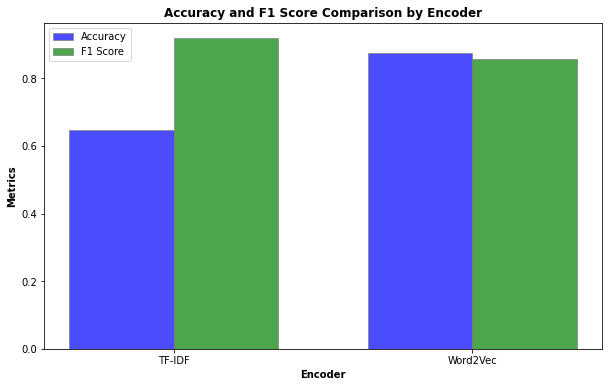

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# Data
encoders = ['TF-IDF', 'Word2Vec']
accuracy_values = [0.647059, 0.873800]
f1_score_values = [0.918347, 0.856650]

# Width of the bars
bar_width = 0.35

# Set the positions of the bars
r1 = np.arange(len(encoders))
r2 = [x + bar_width for x in r1]

# Plotting the side-by-side bar graph
plt.figure(figsize=(10, 6))

# Plotting accuracy
plt.bar(r1, accuracy_values, color='blue', width=bar_width, edgecolor='grey', alpha=0.7, label='Accuracy')

# Plotting F1 score
plt.bar(r2, f1_score_values, color='green', width=bar_width, edgecolor='grey', alpha=0.7, label='F1 Score')

# Adding labels and title
plt.xlabel('Encoder', fontweight='bold')
plt.ylabel('Metrics', fontweight='bold')
plt.title('Accuracy and F1 Score Comparison by Encoder', fontweight='bold')
plt.xticks([r + bar_width / 2 for r in range(len(encoders))], encoders)

# Adding legend
plt.legend()

# Displaying the plot
plt.show()
